In [173]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, balanced_accuracy_score, f1_score
from os import listdir
import cv2
import os

Global variables

In [174]:
RANDOM_SEED = 0
IMG_SIZE = (256, 256)
LABEL2IDX = {
    "Apple___healthy": 0,
    "Apple___Black_rot": 1
    }

Data Preproccesing
Extracting features from the images

In [175]:
from pathlib import Path

SEPARATOR = '/'


X = []
y = []

for d in listdir("data"):
    path = "data"+SEPARATOR+d+SEPARATOR
    if not os.path.isdir(path):
        continue
    imagesize = None
    for f in listdir(path):
        if ".JPG" in f:
            x = cv2.imread(path+f, cv2.IMREAD_GRAYSCALE) # read the image as grayscale
            currentSize = x.shape
            if imagesize is None:
                imagesize = currentSize
                print(f"imsize = {imagesize}, for {d}")
            elif imagesize != currentSize:
                print(f"Image {f} has size {currentSize} but expected {imagesize}. Skipping.")
                continue
            x = x.reshape(256*256,) # reshape to flatten the 256x256 pixel-matrix to a 1d array
            X.append(x)
            y.append(LABEL2IDX[d])


X = np.array(X)
y = np.array(y)

imsize = (256, 256), for Apple___Black_rot
imsize = (256, 256), for Apple___healthy


In [176]:
X.shape

(2266, 65536)

In [177]:
y.shape

(2266,)

Splitting and normalizing the dataset

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=RANDOM_SEED, stratify=y)

print(X_train.max())
print(X_train.min())
print(X_test.max())
print(X_test.min())

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

X_train.max()
X_train.min()

print(X_train.max())
print(X_train.min())
print(X_test.max())
print(X_test.min())



255
0
255
0
4.212719053880333
-4.484240113608423
4.194210288601232
-4.501962038419668


ML Algorithm

In [179]:
Ks = [1, 2, 3, 4, 5, 10, 12, 15, 20, 30, 50, 100, 150, 170, 200]

rows = []

for K in Ks:
    knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
    knn.fit(X_train, y_train)

    # predictions
    y_pred_train = knn.predict(X_train)
    y_proba_train = knn.predict_proba(X_train)

    y_pred_test = knn.predict(X_test)
    y_proba_test = knn.predict_proba(X_test)

    labels = knn.classes_

    rows.append({
        "K": K,

        # TRAIN metrics
        "train_acc": accuracy_score(y_train, y_pred_train),
        "train_bal_acc": balanced_accuracy_score(y_train, y_pred_train),
        "train_f1_macro": f1_score(y_train, y_pred_train, average="macro"),
        "train_logloss": log_loss(y_train, y_proba_train, labels=labels),

        # TEST metrics
        "test_acc": accuracy_score(y_test, y_pred_test),
        "test_bal_acc": balanced_accuracy_score(y_test, y_pred_test),
        "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
        "test_logloss": log_loss(y_test, y_proba_test, labels=labels),
    })

df = pd.DataFrame(rows).set_index("K")

# nicer formatting for visualization
df = df.round({
    "train_acc": 3,
    "train_bal_acc": 3,
    "train_f1_macro": 3,
    "train_logloss": 6,
    "test_acc": 3,
    "test_bal_acc": 3,
    "test_f1_macro": 3,
    "test_logloss": 6,
})

df

KeyboardInterrupt: 

In [ ]:
lr = LogisticRegression(penalty='l2')

lr.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_proba_train = knn.predict_proba(X_train)

y_pred_test = knn.predict(X_test)
y_proba_test = knn.predict_proba(X_test)

# TRAIN metrics

print(f"train accuracy: {accuracy_score(y_train, y_pred_train)}")
print(f"train balanced accuracy: {balanced_accuracy_score(y_train, y_pred_train)}")
print(f"train_f1_macro: {f1_score(y_train, y_pred_train)}")
print(f"train_logloss: {log_loss(y_train, y_proba_train, labels=labels)}")

# TEST metrics
print(f"test_acc: {accuracy_score(y_test, y_pred_test)}"),
print(f"test_bal_acc: {balanced_accuracy_score(y_test, y_pred_test)}"),
print(f"test_f1_macro: {f1_score(y_test, y_pred_test)}")
print(f"test_logloss: {log_loss(y_test, y_proba_test, labels=labels)}")


/Users/lorenzoguimaraes/Documents/code/AI/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


train accuracy: 1.0
train balanced accuracy: 1.0
train_f1_macro: 1.0
train_logloss: 2.871519345809458e-07
test_acc: 0.7761852260198456
test_bal_acc: 0.5923694779116466
test_f1_macro: 0.31186440677966104
test_logloss: 0.46372168207752595


# Scatter Plot

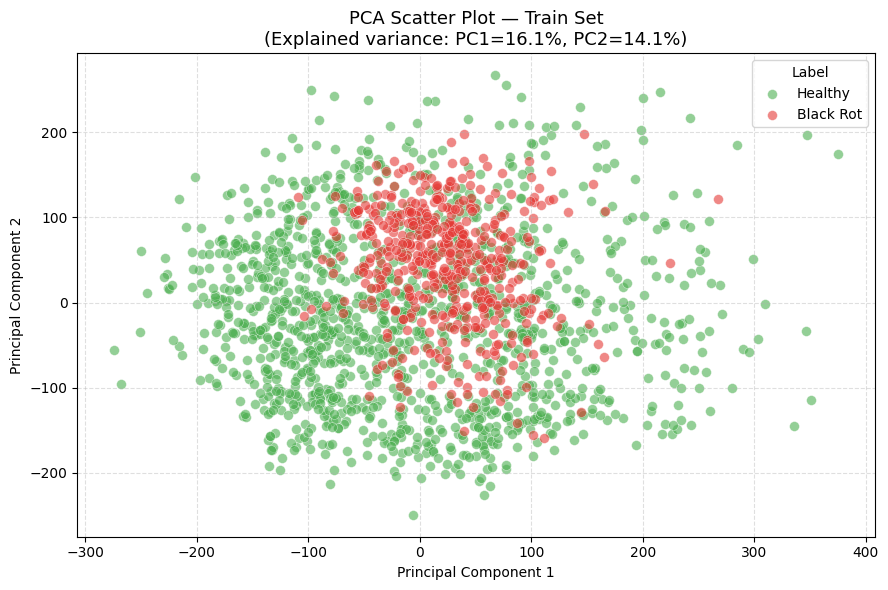

Total variance explained: 30.1%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

colors = {0: '#4CAF50', 1: '#E53935'}
labels_name = {0: 'Healthy', 1: 'Black Rot'}

for label, color in colors.items():
    mask = y_train == label
    ax.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        c=color,
        label=labels_name[label],
        alpha=0.6,
        edgecolors='white',
        linewidths=0.4,
        s=50
    )

ax.set_title(
    f'PCA Scatter Plot — Train Set\n'
    f'(Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, '
    f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%)',
    fontsize=13
)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Label')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss

# Reduce dimensions
pca = PCA(n_components=100, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train)  # X_train already scaled by your StandardScaler
X_test_pca = pca.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf', C=10, gamma='scale',
          class_weight='balanced',
          probability=True,
          random_state=RANDOM_SEED)
svm.fit(X_train_pca, y_train)

# Predictions
y_pred_train = svm.predict(X_train_pca)
y_proba_train = svm.predict_proba(X_train_pca)
y_pred_test = svm.predict(X_test_pca)
y_proba_test = svm.predict_proba(X_test_pca)

# Metrics
print("=== SVM Results ===")
print(f"train accuracy:          {accuracy_score(y_train, y_pred_train):.4f}")
print(f"train balanced accuracy: {balanced_accuracy_score(y_train, y_pred_train):.4f}")
print(f"train f1 macro:          {f1_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"train logloss:           {log_loss(y_train, y_proba_train):.6f}")
print()
print(f"test accuracy:           {accuracy_score(y_test, y_pred_test):.4f}")
print(f"test balanced accuracy:  {balanced_accuracy_score(y_test, y_pred_test):.4f}")
print(f"test f1 macro:           {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"test logloss:            {log_loss(y_test, y_proba_test):.6f}")

=== SVM Results ===
train accuracy:          1.0000
train balanced accuracy: 1.0000
train f1 macro:          1.0000
train logloss:           0.007202

test accuracy:           0.9648
test balanced accuracy:  0.9456
test f1 macro:           0.9547
test logloss:            0.111556


In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss

# Reduce dimensions (reuse pca from above if already run, otherwise fit again)
pca_rf = PCA(n_components=100, random_state=RANDOM_SEED)
X_train_pca_rf = pca_rf.fit_transform(X_train)
X_test_pca_rf = pca_rf.transform(X_test)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200,
                             class_weight='balanced',
                             random_state=RANDOM_SEED,
                             n_jobs=-1)  # uses all CPU cores
rf.fit(X_train_pca_rf, y_train)

# Predictions
y_pred_train = rf.predict(X_train_pca_rf)
y_proba_train = rf.predict_proba(X_train_pca_rf)
y_pred_test = rf.predict(X_test_pca_rf)
y_proba_test = rf.predict_proba(X_test_pca_rf)

# Metrics
print("=== Random Forest Results ===")
print(f"train accuracy:          {accuracy_score(y_train, y_pred_train):.4f}")
print(f"train balanced accuracy: {balanced_accuracy_score(y_train, y_pred_train):.4f}")
print(f"train f1 macro:          {f1_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"train logloss:           {log_loss(y_train, y_proba_train):.6f}")
print()
print(f"test accuracy:           {accuracy_score(y_test, y_pred_test):.4f}")
print(f"test balanced accuracy:  {balanced_accuracy_score(y_test, y_pred_test):.4f}")
print(f"test f1 macro:           {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"test logloss:            {log_loss(y_test, y_proba_test):.6f}")

=== Random Forest Results ===
train accuracy:          1.0000
train balanced accuracy: 1.0000
train f1 macro:          1.0000
train logloss:           0.100543

test accuracy:           0.8480
test balanced accuracy:  0.7265
test f1 macro:           0.7639
test logloss:            0.334992


In [189]:
for d in listdir("test"):
    path = "test"+SEPARATOR+d
    if ".JPG" in path:
            x = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # read the image as grayscale
            x = x.reshape(256*256,) # reshape to flatten the 256x256 pixel-matrix to a 1d array
            x = ss.transform([x])  # standardize using the same scaler as training data
            x_pca = pca_rf.transform(x)  # apply PCA transformation
            prediction = rf.predict_proba(x_pca)  # predict using the trained Random Forest
            print(f"Image: {d}, Prediction (probabilities): {prediction}")

Image: applerot101.JPG, Prediction (probabilities): [[0.535 0.465]]
Image: applehealthy101.JPG, Prediction (probabilities): [[0.995 0.005]]
Image: applehealthy10.JPG, Prediction (probabilities): [[0.915 0.085]]
Image: applehealthy1010.JPG, Prediction (probabilities): [[0.755 0.245]]
Image: applerot10.JPG, Prediction (probabilities): [[0.19 0.81]]
Image: applehealthy1.JPG, Prediction (probabilities): [[0.935 0.065]]
Image: applerot1.JPG, Prediction (probabilities): [[0.815 0.185]]
Image: applerot1010.JPG, Prediction (probabilities): [[0.355 0.645]]
